In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
%matplotlib inline

In [23]:
df = pd.read_csv("27-mall_customers.csv")

In [24]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [26]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

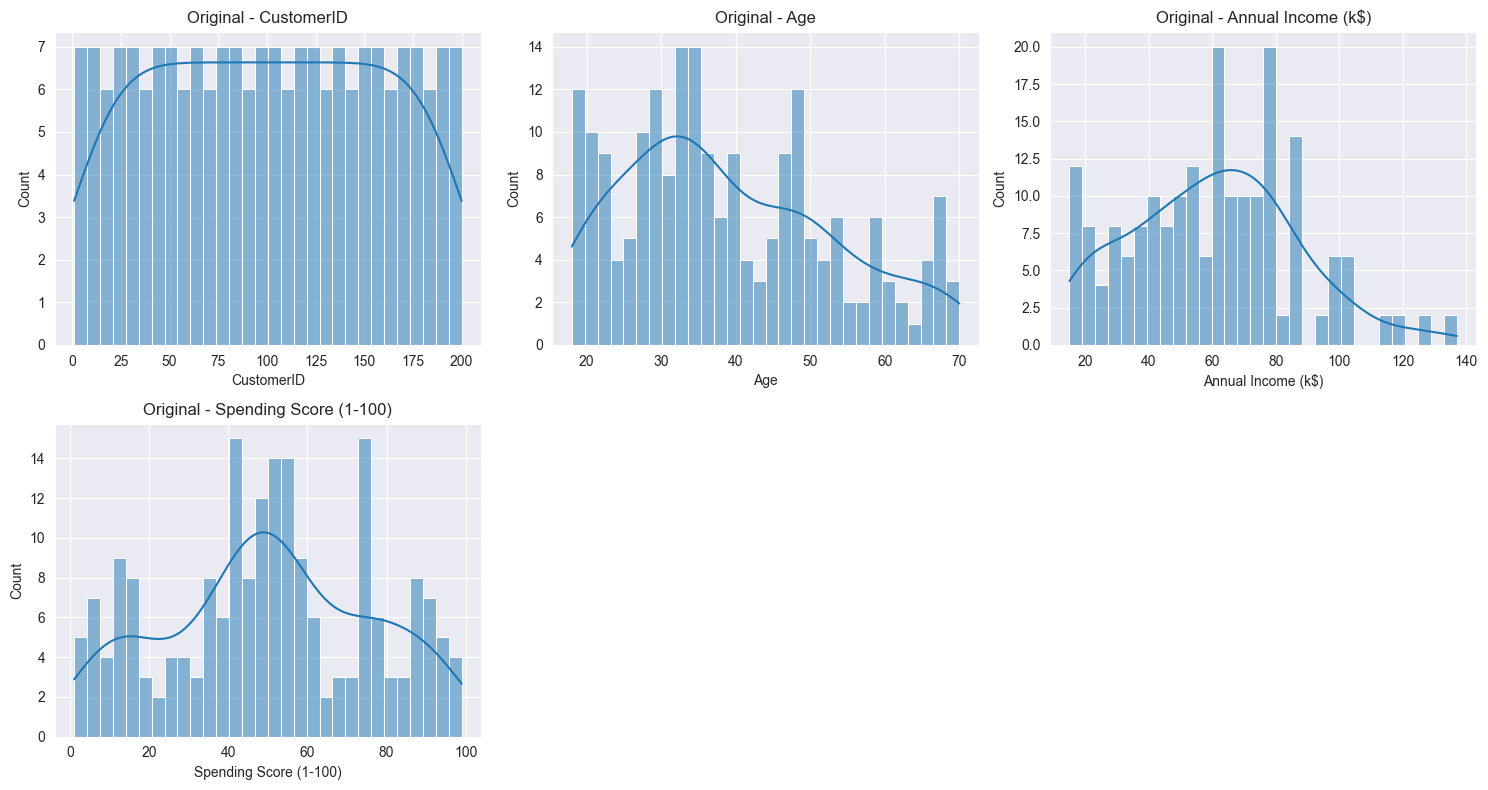

In [27]:
import math

def plot_all_histograms(df,title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for x, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, x)
        sns.histplot(df[col], bins=30,kde=True)
        plt.title(f"{title_prefix}{col}" )

    plt.tight_layout()
    plt.show()

plot_all_histograms(df,title_prefix="Original - ")

In [28]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [29]:
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
df["Gender"] = enc.fit_transform(df["Gender"])

In [34]:
df = df.drop("CustomerID", axis=1)

In [35]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

df = pd.DataFrame(df_scaled, columns=df.columns)

In [37]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020
3,0.0,0.096154,0.008197,0.775510
4,0.0,0.250000,0.016393,0.397959


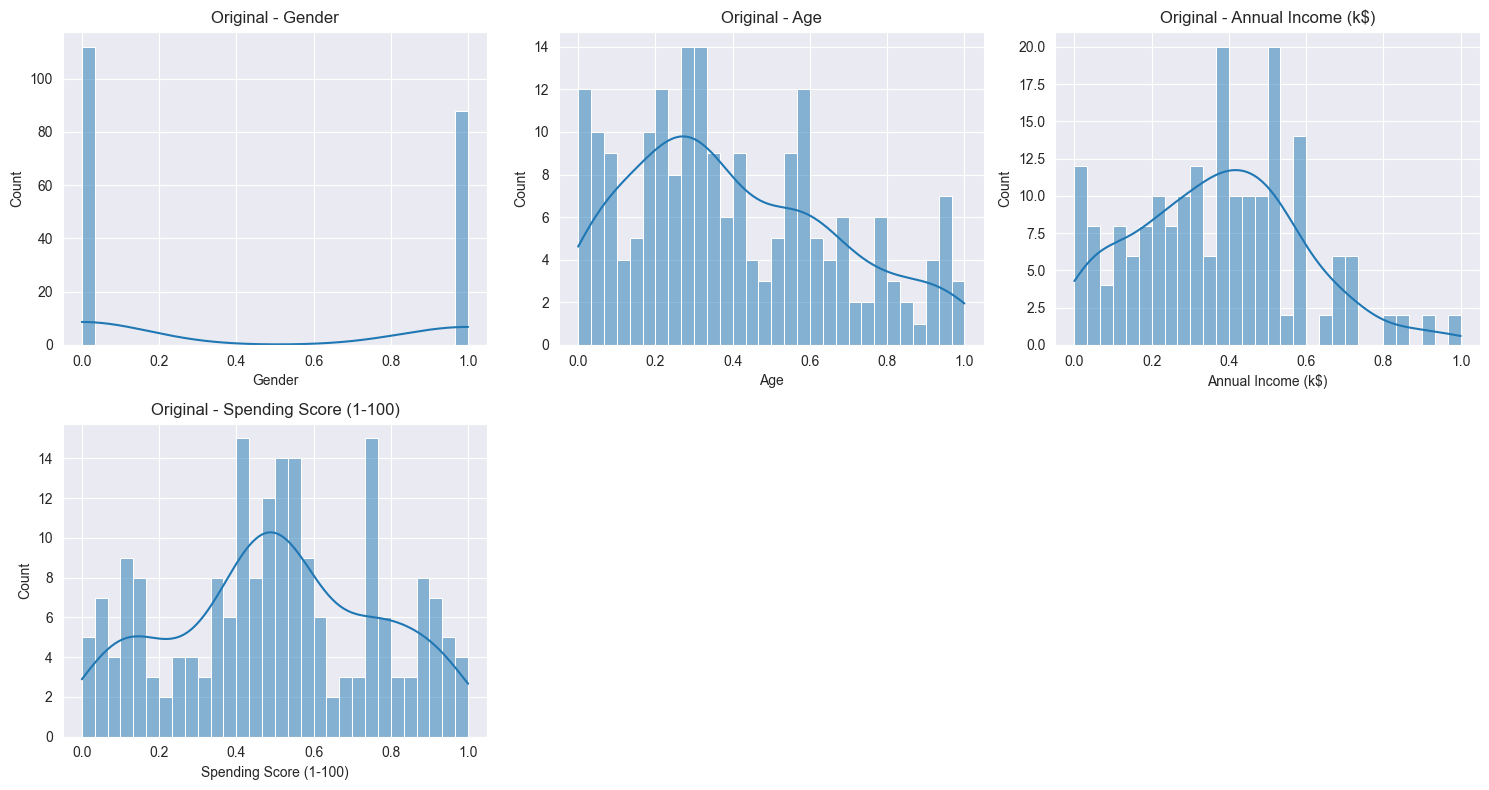

In [38]:
import math

def plot_all_histograms(df,title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for x, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, x)
        sns.histplot(df[col], bins=30,kde=True)
        plt.title(f"{title_prefix}{col}" )

    plt.tight_layout()
    plt.show()

plot_all_histograms(df,title_prefix="Original - ")

In [41]:
import scipy.cluster.hierarchy as sch

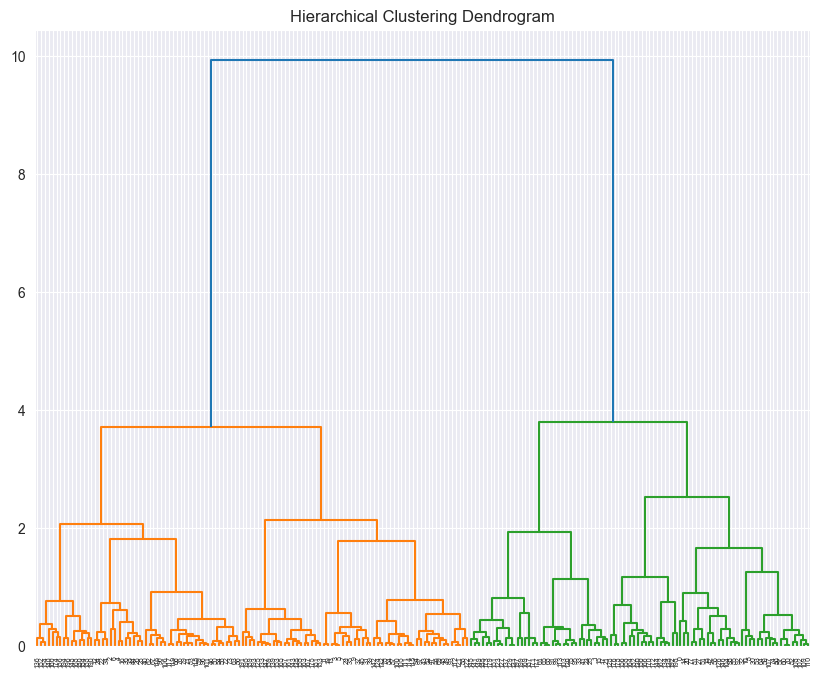

In [43]:
plt.figure(1, figsize=(10, 8))
dendogram = sch.dendrogram(sch.linkage(df,method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [44]:
#we can select 4-6 clusters this dendogram

In [45]:
from sklearn.cluster import AgglomerativeClustering

In [46]:
hc = AgglomerativeClustering(n_clusters=4)

In [51]:
y_hc = hc.fit_predict(df)

In [52]:
df["cluster"] = pd.DataFrame(y_hc)

In [53]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1.0,0.019231,0.000000,0.387755,0
1,1.0,0.057692,0.000000,0.816327,2
2,0.0,0.038462,0.008197,0.051020,3
3,0.0,0.096154,0.008197,0.775510,1
4,0.0,0.250000,0.016393,0.397959,3


Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram')

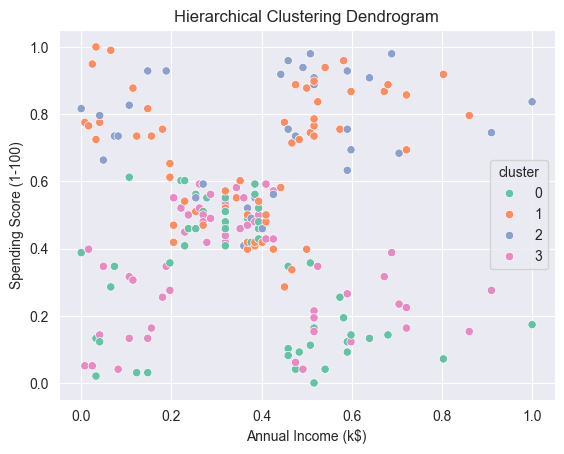

In [57]:
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette="Set2")
plt.title("Hierarchical Clustering Dendrogram")

In [58]:
from sklearn.metrics import silhouette_score
print(silhouette_score(df, y_hc))

0.7143503785893516


In [59]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

In [60]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.387755
1,0.000000,0.816327
2,0.008197,0.051020
3,0.008197,0.775510
4,0.016393,0.397959


In [64]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X)
X["cluster"] = y_hc

In [65]:
X

,Annual Income (k$),Spending Score (1-100),cluster
0,0.000000,0.387755,4
1,0.000000,0.816327,3
2,0.008197,0.051020,4
3,0.008197,0.775510,3
4,0.016393,0.397959,4
...,...,...,...
195,0.860656,0.795918,0
196,0.909836,0.275510,1
197,0.909836,0.744898,0
198,1.000000,0.173469,1


Text(0.5, 1.0, 'Hierarchical Clustering Dendrogram')

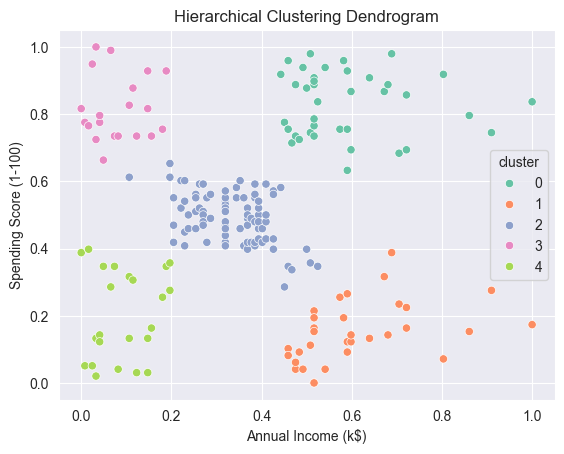

In [66]:
sns.scatterplot(data=X, x="Annual Income (k$)", y="Spending Score (1-100)", hue="cluster", palette="Set2")
plt.title("Hierarchical Clustering Dendrogram")

In [67]:
print(silhouette_score(X, y_hc))

0.8524094908064438


In [68]:
from sklearn.metrics import calinski_harabasz_score,davies_bouldin_score

In [69]:
df = pd.read_csv("27-mall_customers.csv")
df = df.drop("CustomerID", axis=1)
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

features_2D =["Annual Income (k$)", "Spending Score (1-100)"]
features_3D = ["Annual Income (k$)", "Spending Score (1-100)","Age"]
features_4D = ["Annual Income (k$)", "Spending Score (1-100)","Age","Gender"]

for feats in [features_2D, features_3D, features_4D]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    hc = AgglomerativeClustering(n_clusters=5)
    y_hc = hc.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, y_hc)
    db = davies_bouldin_score(X_scaled, y_hc)
    ch = calinski_harabasz_score(X_scaled, y_hc)

    print(f"\n features: {feats}")
    print(f"\n silhouette_score: {sil}")
    print(f"\n davies_bouldin_score: {db}")
    print(f"\n calinski_harabasz_score: {ch}")
    print("--------------------------")


 features: ['Annual Income (k$)', 'Spending Score (1-100)']

 silhouette_score: 0.5582698727196419

 davies_bouldin_score: 0.5734519252471811

 calinski_harabasz_score: 258.97400737720704
--------------------------

 features: ['Annual Income (k$)', 'Spending Score (1-100)', 'Age']

 silhouette_score: 0.3955454334726547

 davies_bouldin_score: 0.8746143334035461

 calinski_harabasz_score: 123.99070840826576
--------------------------

 features: ['Annual Income (k$)', 'Spending Score (1-100)', 'Age', 'Gender']

 silhouette_score: 0.3503244750715629

 davies_bouldin_score: 1.0941951795238571

 calinski_harabasz_score: 163.46602356383622
--------------------------


In [70]:
from sklearn.cluster import KMeans

In [71]:
df = pd.read_csv("27-mall_customers.csv")
df = df.drop("CustomerID", axis=1)
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

features_2D =["Annual Income (k$)", "Spending Score (1-100)"]
features_3D = ["Annual Income (k$)", "Spending Score (1-100)","Age"]
features_4D = ["Annual Income (k$)", "Spending Score (1-100)","Age","Gender"]

for feats in [features_2D, features_3D, features_4D]:
    X = df[feats]
    X_scaled = MinMaxScaler().fit_transform(X)

    kmeans = KMeans(n_clusters=5)
    y_hc = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, y_hc)
    db = davies_bouldin_score(X_scaled, y_hc)
    ch = calinski_harabasz_score(X_scaled, y_hc)

    print(f"\n features: {feats}")
    print(f"\n silhouette_score: {sil}")
    print(f"\n davies_bouldin_score: {db}")
    print(f"\n calinski_harabasz_score: {ch}")
    print("--------------------------")


 features: ['Annual Income (k$)', 'Spending Score (1-100)']

 silhouette_score: 0.5593469429051445

 davies_bouldin_score: 0.5616471225010365

 calinski_harabasz_score: 264.55064767750844
--------------------------

 features: ['Annual Income (k$)', 'Spending Score (1-100)', 'Age']

 silhouette_score: 0.4058812015258782

 davies_bouldin_score: 0.9361270042587135

 calinski_harabasz_score: 126.05974459737254
--------------------------

 features: ['Annual Income (k$)', 'Spending Score (1-100)', 'Age', 'Gender']

 silhouette_score: 0.3708946469889692

 davies_bouldin_score: 0.9954096267348435

 calinski_harabasz_score: 172.92326859199304
--------------------------
